# Dogs vs Cats Classification

### step 1 - libraries import

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


2026-06-20 12:02:16.921695: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781956937.098886      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781956937.161622      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781956937.604300      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781956937.604335      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781956937.604338      58 computation_placer.cc:177] computation placer alr

### step 2 - dataset ka path

In [46]:
train_path = "/kaggle/input/datasets/salader/dogsvscats/train"
test_path = "/kaggle/input/datasets/salader/dogsvscats/test"


### step 3 - images ko load karna

ImageDataGenerator images ko load karta he aur 0-1 range me convert karta he (rescale)
flow_from_directory folder ka naam hi label bana deta he (cats/dogs)

In [15]:
data = ImageDataGenerator(rescale=1./255,
                              validation_split=0.2,
                              rotation_range=20,
                              zoom_range=0.2,
                              horizontal_flip=True)

train_data = data.flow_from_directory("/kaggle/input/datasets/salader/dogsvscats/train",
                                          target_size=(150,150),
                                          batch_size=32,
                                          class_mode='binary',
                                          subset='training')

val_data = data.flow_from_directory("/kaggle/input/datasets/salader/dogsvscats/train",
                                        target_size=(150,150),
                                        batch_size=32,
                                        class_mode='binary',
                                        subset='validation')

Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.


### step 4 - kuch images dekhte hain

bas check karne ke liye ke data sahi load hua he

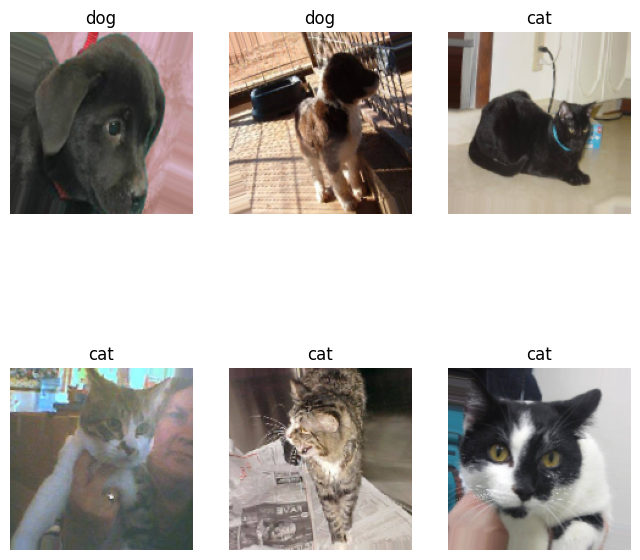

In [25]:
img, label = next(train_data)

plt.figure(figsize=(8,8))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(img[i])
    plt.title("dog" if label[i]==1 else "cat")
    plt.axis('off')


### step 5 - model banate hain (CNN)

Conv2D layer image ke features pakarti he (lines, shapes wagera)
MaxPooling image ko chota karti he
Flatten 2D ko 1D me convert karti he
last layer sigmoid use karti he kyu k answer 0 ya 1 me chahiye (cat ya dog)

In [26]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

### step 6 - model compile karna

adam optimizer training ko handle karta he
binary_crossentropy loss isliye use ki kyu k 2 classes hain (cat/dog)

In [30]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


### step 7 - training

epochs=15 matlab model pura dataset 15 dafa dekhega (max)
lekin EarlyStopping lagaya he, agar validation loss barhna shuru ho jaye to training khud hi ruk jayegi (overfitting se bachne ke liye), isliye ho sakta he 15 se pehle hi ruk jaye

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(train_data,
                     validation_data=val_data,
                     epochs=15,
                     callbacks=[early_stop])


Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 129s 250ms/step - accuracy: 0.5719 - loss: 0.6838 - val_accuracy: 0.6447 - val_loss: 0.6389
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 125s 249ms/step - accuracy: 0.6781 - loss: 0.6044 - val_accuracy: 0.7157 - val_loss: 0.5595
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 126s 252ms/step - accuracy: 0.7346 - loss: 0.5397 - val_accuracy: 0.7695 - val_loss: 0.4874
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 124s 249ms/step - accuracy: 0.7560 - loss: 0.5076 - val_accuracy: 0.7707 - val_loss: 0.4798
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 124s 248ms/step - accuracy: 0.7687 - loss: 0.4821 - val_accuracy: 0.8037 - val_loss: 0.4406
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 126s 251ms/step - accuracy: 0.7928 - loss: 0.4525 - val_accuracy: 0.7952 - val_loss: 0.4419
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 126s 252ms/step - accuracy: 0.8014 - loss: 0.4370 - val_accuracy: 0.7835 - val_loss: 0.4456
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 123s 247ms/step - accuracy: 0.8161 -

### step 8 - accuracy ka graph

dekhte hain training kaisi gayi

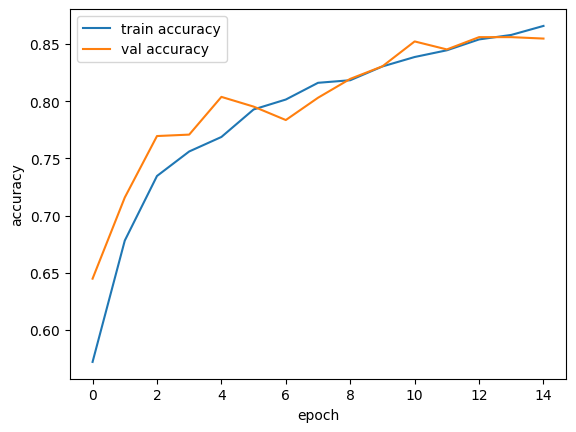

In [47]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()


### step 9 - ek image pe test karna

test folder se koi bhi image utha k check kar sakte hain

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


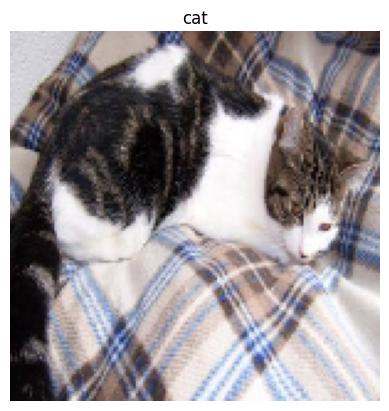

In [50]:
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# yahan apni image ka naam/path daal dein, test folder me se koi bhi
test_img_path = test_path + "/cats/" + os.listdir(test_path + "/cats")[0]

img = image.load_img(test_img_path, target_size=(150,150))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

plt.imshow(img)
plt.axis('off')

if pred[0][0] > 0.5:
    plt.title("dog")
else:
    plt.title("cat")